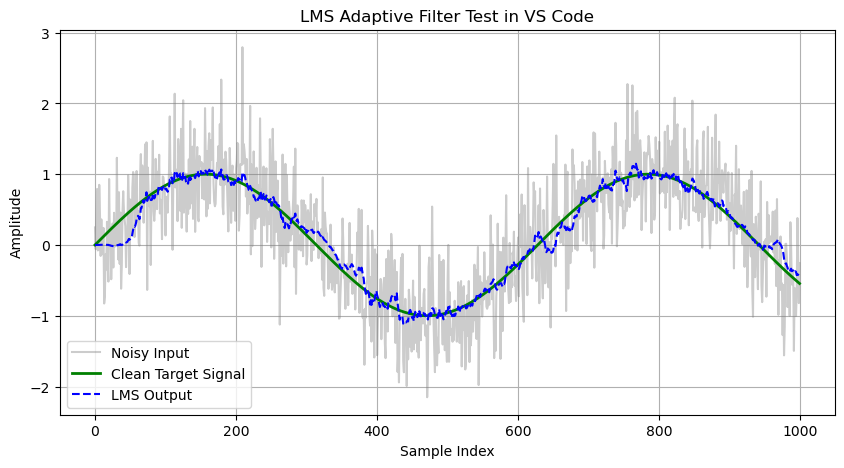

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define LMS Filter Class
class LMSFilter:
    def __init__(self, num_taps: int, mu: float):
        self.num_taps = num_taps
        self.mu = mu
        self.w = np.zeros(num_taps)

    def adapt(self, x: np.ndarray, d: np.ndarray):
        n_samples = len(x)
        y = np.zeros(n_samples)
        e = np.zeros(n_samples)
        x_buf = np.zeros(self.num_taps)

        for n in range(n_samples):
            x_buf[1:] = x_buf[:-1]
            x_buf[0] = x[n]
            y[n] = np.dot(self.w, x_buf)
            e[n] = d[n] - y[n]
            self.w += 2 * self.mu * e[n] * x_buf

        return y, e

# 2. Generate Noisy Test Signals
np.random.seed(42)
N = 1000
time = np.linspace(0, 10, N)
clean_signal = np.sin(time)
noise = np.random.normal(0, 0.5, N)
noisy_signal = clean_signal + noise

# 3. Run LMS Filter
lms = LMSFilter(num_taps=16, mu=0.01)
output_signal, error_signal = lms.adapt(x=noisy_signal, d=clean_signal)

# 4. Plot Results
plt.figure(figsize=(10, 5))
plt.plot(noisy_signal, label="Noisy Input", alpha=0.4, color="gray")
plt.plot(clean_signal, label="Clean Target Signal", color="green", linewidth=2)
plt.plot(output_signal, label="LMS Output", color="blue", linestyle="--")
plt.title("LMS Adaptive Filter Test in VS Code")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

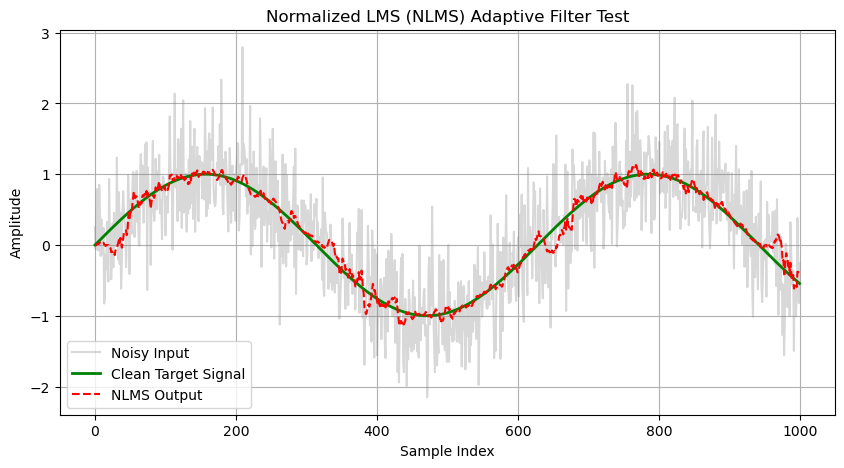

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- Normalized LMS (NLMS) Class Definition ---
class NLMSFilter:
    def __init__(self, num_taps: int, mu: float, eps: float = 1e-6):
        """
        num_taps: Filter length
        mu: Normalized step size (0 < mu < 2)
        eps: Small constant to prevent division by zero (regularization)
        """
        self.num_taps = num_taps
        self.mu = mu
        self.eps = eps
        self.w = np.zeros(num_taps)

    def adapt(self, x: np.ndarray, d: np.ndarray):
        n_samples = len(x)
        y = np.zeros(n_samples)
        e = np.zeros(n_samples)
        x_buf = np.zeros(self.num_taps)

        for n in range(n_samples):
            # Update input delay line buffer
            x_buf[1:] = x_buf[:-1]
            x_buf[0] = x[n]

            # Compute output and error
            y[n] = np.dot(self.w, x_buf)
            e[n] = d[n] - y[n]

            # Input vector energy norm: ||x||^2
            norm_x = np.dot(x_buf, x_buf)

            # Normalized weight update rule:
            # w(n+1) = w(n) + (mu / (||x||^2 + eps)) * e(n) * x(n)
            self.w += (self.mu / (norm_x + self.eps)) * e[n] * x_buf

        return y, e

# --- Test NLMS vs Standard LMS ---
np.random.seed(42)
N = 1000
time = np.linspace(0, 10, N)
clean_signal = np.sin(time)
noisy_signal = clean_signal + np.random.normal(0, 0.5, N)

# Run NLMS Filter
nlms = NLMSFilter(num_taps=16, mu=0.5)
y_nlms, e_nlms = nlms.adapt(x=noisy_signal, d=clean_signal)

# Plot NLMS Performance
plt.figure(figsize=(10, 5))
plt.plot(noisy_signal, label="Noisy Input", alpha=0.3, color="gray")
plt.plot(clean_signal, label="Clean Target Signal", color="green", linewidth=2)
plt.plot(y_nlms, label="NLMS Output", color="red", linestyle="--")

plt.title("Normalized LMS (NLMS) Adaptive Filter Test")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()